---

In [ ]:
import tensorflow as tf

tfrecord_files = [
    "/pdo/users/pablomer/mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-april2025-val/00000-of-00005"
]

# Dictionary to hold feature data
example_data = {}

raw_dataset = tf.data.TFRecordDataset(tfrecord_files)

for raw_record in raw_dataset.take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())

    for key, feature in example.features.feature.items():
        if feature.HasField("float_list"):
            example_data[key] = list(feature.float_list.value)
        elif feature.HasField("int64_list"):
            example_data[key] = list(feature.int64_list.value)
        elif feature.HasField("bytes_list"):
            example_data[key] = [v.decode("utf-8") for v in feature.bytes_list.value]
        else:
            example_data[key] = None  # unknown type


2025-04-23 16:39:26.071711: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Scalar Features:
  disp_p: 0
  disp_b: 0
  disp_e: 0
  disp_n: 0
  disp_t: 0
  disp_u: 0
  disp_j: 1


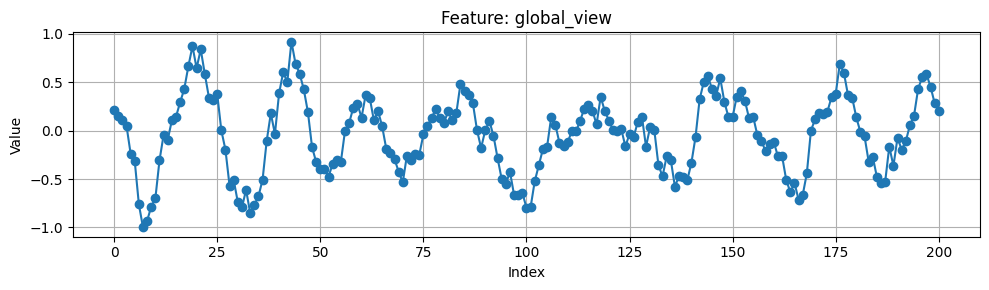

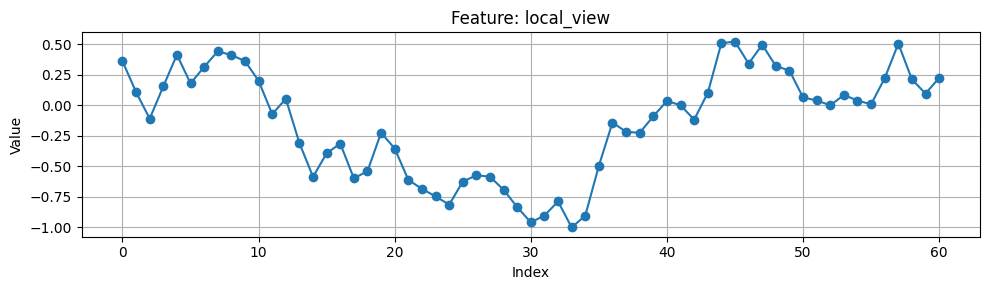

In [ ]:
import matplotlib.pyplot as plt

def inspect_features(feature_names, max_points=None):
    """
    For each feature in feature_names:
      - If the feature is scalar (only one value), store it in a dictionary.
      - If the feature has more than one value, prepare it for plotting.

    Args:
      feature_names (list of str): List of feature names to inspect.
      max_points (int, optional): If provided, limits the number of data points plotted.
    """
    scalars = {}
    sequences = []

    for name in feature_names:
        if name not in example_data:
            print(f"Feature '{name}' not found.")
            continue

        data = example_data[name]
        # Ensure data is in list format
        if not isinstance(data, list):
            data = [data]

        if len(data) == 1:
            scalars[name] = data[0]
        else:
            sequences.append((name, data))

    # Print all scalar features together
    if scalars:
        print("Scalar Features:")
        for key, val in scalars.items():
            print(f"  {key}: {val}")
    else:
        print("No scalar features found.")

    # Now, plot each non-scalar feature
    for name, data in sequences:
        plot_data = data[:max_points] if max_points is not None else data
        plt.figure(figsize=(10, 3))
        plt.plot(plot_data, marker='o')
        plt.title(f"Feature: {name}")
        plt.xlabel("Index")
        plt.ylabel("Value")
        plt.grid(True)
        plt.tight_layout()
        plt.show()



# Example usage:
# plot_feature("global_view")
# plot_feature("local_view")
# plot_feature("local_view")
# You can also call: plot_feature("local_view_half_period_0.3")

# features_list=['local_view', 'local_aperture_l', 'local_scale_present', 'secondary_std', 'local_scale_present_0.3', 'local_std', 'global_view_double_period', 'star_mass_present', 'local_std_even', 'global_view_half_period_0.3', 'local_view_half_period_0.3', 'local_mask', 'secondary_view_0.3', 'global_view_double_period_mask_0.3', 'global_view_double_period_mask', 'local_aperture_m_0.3', 'global_view_0.3', 'astro_id', 'local_std_odd', 'local_view_odd', 'global_view_double_period_std_0.3', 'disp_p', 'local_std_odd_0.3', 'global_view_half_period', 'star_rad', 'disp_b', 'disp_e', 'global_view_double_period_mask_5.0', 'secondary_scale_5.0', 'global_mask_5.0', 'local_aperture_l_5.0', 'local_mask_odd', 'global_view_half_period_std', 'local_mask_5.0', 'disp_u', 'star_rad_est', 'local_view_half_period_5.0', 'local_view_half_period_std_5.0', 'global_view_half_period_5.0', 'secondary_view_5.0', 'local_view_odd_5.0', 'local_std_even_5.0', 'local_view_even_5.0', 'local_view_even', 'global_transit_mask_5.0', 'global_view_half_period_mask_0.3', 'secondary_scale_present_0.3', 'global_transit_mask', 'local_view_even_0.3', 'local_aperture_l_0.3', 'secondary_phase_5.0', 'global_mask_0.3', 'global_view_double_period_std', 'secondary_scale_present_5.0', 'n_points', 'secondary_phase_0.3', 'local_scale_present_5.0', 'secondary_std_0.3', 'local_mask_0.3', 'local_std_even_0.3', 'secondary_mask_0.3', 'local_aperture_m_5.0', 'local_mask_even_0.3', 'global_std_5.0', 'local_mask_odd_5.0', 'global_view', 'secondary_scale_present', 'secondary_mask_5.0', 'local_std_0.3', 'secondary_mask', 'Period', 'sample_segments_view', 'secondary_std_5.0', 'local_view_half_period_std', 'global_view_half_period_std_0.3', 'local_view_half_period_mask_0.3', 'local_view_half_period_mask', 'sample_segments_local_view_5.0', 'local_view_0.3', 'n_folds', 'local_mask_odd_0.3', 'secondary_phase', 'star_rad_present', 'disp_n', 'global_view_5.0', 'star_rad_est_present', 'global_view_double_period_5.0', 'local_view_half_period_std_0.3', 'local_mask_even', 'sample_segments_local_view_0.3', 'local_scale_0.3', 'local_scale', 'local_view_half_period', 'global_view_double_period_std_5.0', 'Duration', 'global_view_half_period_mask', 'local_view_half_period_mask_5.0', 'sample_segments_view_0.3', 'local_aperture_s_5.0', 'local_std_odd_5.0', 'Tmag', 'local_std_5.0', 'secondary_scale', 'local_view_5.0', 'Transit_Depth', 'global_mask', 'star_mass', 'local_aperture_m', 'sample_segments_view_5.0', 'global_view_half_period_std_5.0', 'local_aperture_s', 'local_aperture_s_0.3', 'disp_t', 'global_std_0.3', 'global_std', 'sample_segments_local_view', 'local_view_odd_0.3', 'global_view_double_period_0.3', 'global_transit_mask_0.3', 'local_scale_5.0', 'secondary_view', 'global_view_half_period_mask_5.0', 'disp_j', 'local_mask_even_5.0', 'secondary_scale_0.3']

features_list = [
    # Basic TCE metadata:
    'astro_id',
    'Period',
    'Duration',
    'Transit_Depth',
    'Tmag',
    'n_points',
    'n_folds',

    # Disposition / diagnostic flags:
    'disp_p', 'disp_b', 'disp_e', 'disp_n', 'disp_t', 'disp_u', 'disp_j',

    # Star properties:
    'star_mass', 'star_mass_present',
    'star_rad', 'star_rad_present',
    'star_rad_est', 'star_rad_est_present',

    # Global views:
    'global_view', 'global_std', 'global_mask', 'global_transit_mask',
    'global_view_0.3', 'global_std_0.3', 'global_mask_0.3',
    'global_view_5.0', 'global_std_5.0', 'global_mask_5.0',
    'global_view_half_period', 'global_view_half_period_0.3', 'global_view_half_period_5.0',
    'global_view_double_period',
    'global_view_double_period_mask',
    'global_view_double_period_mask_0.3',
    'global_view_double_period_mask_5.0',
    'global_view_double_period_std',
    'global_view_double_period_std_0.3',
    'global_view_double_period_std_5.0',

    # Local views:
    'local_view', 'local_std', 'local_mask',
    'local_scale', 'local_scale_present',
    'local_view_even', 'local_std_even', 'local_mask_even',
    'local_view_odd', 'local_std_odd', 'local_mask_odd',
    'local_view_0.3', 'local_std_0.3', 'local_mask_0.3',
    'local_view_5.0', 'local_std_5.0', 'local_mask_5.0',

    # Local views - half period:
    'local_view_half_period',
    'local_view_half_period_0.3', 'local_view_half_period_5.0',
    'local_view_half_period_std',
    'local_view_half_period_std_0.3',
    'local_view_half_period_mask',
    'local_view_half_period_mask_0.3', 'local_view_half_period_mask_5.0',

    # Aperture views:
    'local_aperture_s', 'local_aperture_s_0.3',
    'local_aperture_l', 'local_aperture_l_0.3', 'local_aperture_l_5.0',
    'local_aperture_m', 'local_aperture_m_0.3', 'local_aperture_m_5.0',

    # Secondary views:
    'secondary_view', 'secondary_view_0.3', 'secondary_view_5.0',
    'secondary_std', 'secondary_std_0.3', 'secondary_std_5.0',
    'secondary_mask', 'secondary_mask_0.3', 'secondary_mask_5.0',
    'secondary_scale', 'secondary_scale_0.3', 'secondary_scale_5.0',
    'secondary_scale_present', 'secondary_scale_present_0.3', 'secondary_scale_present_5.0',
    'secondary_phase', 'secondary_phase_0.3', 'secondary_phase_5.0',

    # Sample segments:
    'sample_segments_view', 'sample_segments_view_0.3', 'sample_segments_view_5.0',
    'sample_segments_local_view', 'sample_segments_local_view_0.3', 'sample_segments_local_view_5.0',

    # Miscellaneous:
    'global_transit_mask', 'global_transit_mask_5.0',
]

features_list=['astro_id','disp_p', 'disp_b', 'disp_e', 'disp_n', 'disp_t', 'disp_u', 'disp_j','global_view','local_view']


# for feature in features_list:
#     plot_feature(feature)

inspect_features(features_list)